Импорт библиотек

Подключаются основные библиотеки: pandas и numpy для работы с таблицами и массивами, matplotlib и seaborn для построения графиков, mlxtend - для реализации алгоритмов ассоциативных правил, networkx - для визуализации связей между товарами. Настройка pd.set_option('display.max_columns', None) позволяет выводить все столбцы без обрезки при просмотре DataFrame.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx

pd.set_option('display.max_columns', None)

Загрузка данных

Файл с данными о покупках загружается с помощью pd.read_csv. каждая строка — одна транзакция, каждый столбец — товар.
Всего 9835 покупок, максимум 32 товара в каждой. Пустые ячейки — там, где в чеке было меньше товаров.

In [3]:
# Загрузка CSV файла
all_data = pd.read_csv('groceries - groceries.csv')

# Просмотр первых строк
print(all_data.head())
print(f"\nКоличество строк: {len(all_data)}, количество столбцов: {len(all_data.columns)}")


   Item(s)            Item 1               Item 2          Item 3  \
0        4      citrus fruit  semi-finished bread       margarine   
1        3    tropical fruit               yogurt          coffee   
2        1        whole milk                  NaN             NaN   
3        4         pip fruit               yogurt    cream cheese   
4        4  other vegetables           whole milk  condensed milk   

                     Item 4 Item 5 Item 6 Item 7 Item 8 Item 9 Item 10  \
0               ready soups    NaN    NaN    NaN    NaN    NaN     NaN   
1                       NaN    NaN    NaN    NaN    NaN    NaN     NaN   
2                       NaN    NaN    NaN    NaN    NaN    NaN     NaN   
3              meat spreads    NaN    NaN    NaN    NaN    NaN     NaN   
4  long life bakery product    NaN    NaN    NaN    NaN    NaN     NaN   

  Item 11 Item 12 Item 13 Item 14 Item 15 Item 16 Item 17 Item 18 Item 19  \
0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     N

Анализ и визуализация длин транзакций

Сначала вычисляется, сколько товаров содержится в каждой покупке, считая непустые ячейки. Затем строится гистограмма, которая показывает распределение длин транзакций: сколько клиентов купили 1 товар, 2 товара, 3 и т.д.

Больше всего покупок, где в корзине 2-5 товаров - таких более двух тысяч. Чем длиннее чек, тем реже он встречается. После отметки примерно в 10 товаров количество транзакций резко падает, а покупки с 20 и более позициями почти не встречаются. Это говорит о том, что большинство клиентов совершают небольшие, повседневные покупки, а не делают крупные закупки.

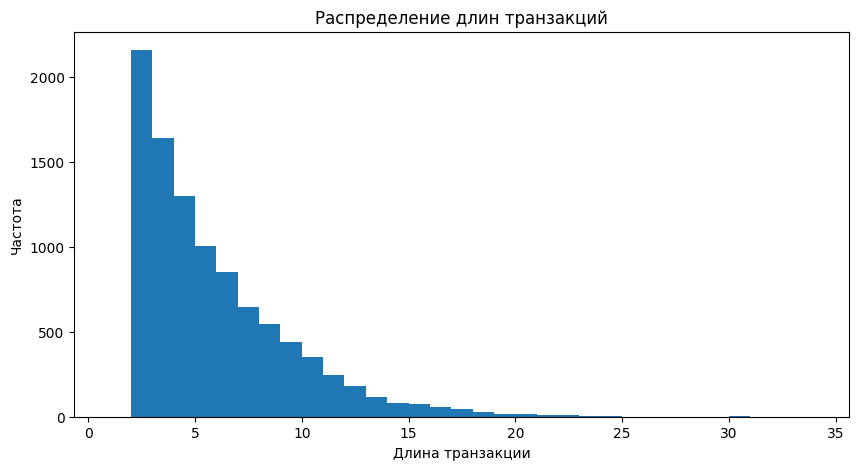

In [4]:
# Подсчет длины каждой транзакции (сколько товаров в каждой строке)
transaction_lengths = all_data.notnull().sum(axis=1)

# Визуализация распределения длин транзакций
plt.figure(figsize=(10, 5))
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths) + 2))
plt.xlabel('Длина транзакции')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.show()


Очистка и подготовка данных

Этот код превращает таблицу покупок в список транзакций, где каждая строка - это список товаров из одной покупки.
Пустые ячейки отбрасываются, остаются только реальные названия товаров.
Затем создается множество всех уникальных товаров, которое сортируется и выводится.
Результат показывает, что в данных 169 разных продуктов - от молочных и мясных до напитков и бытовых товаров.

In [5]:
# Преобразуем DataFrame в список списков (список транзакций)
np_data = all_data.to_numpy()
transactions = [[elem for elem in row[1:] if isinstance(elem, str)] for row in np_data]

# Список уникальных товаров
unique_items = sorted({item for row in transactions for item in row})
print(f"Количество уникальных товаров: {len(unique_items)}")
print(unique_items[:30])


Количество уникальных товаров: 169
['Instant food products', 'UHT-milk', 'abrasive cleaner', 'artif. sweetener', 'baby cosmetics', 'baby food', 'bags', 'baking powder', 'bathroom cleaner', 'beef', 'berries', 'beverages', 'bottled beer', 'bottled water', 'brandy', 'brown bread', 'butter', 'butter milk', 'cake bar', 'candles', 'candy', 'canned beer', 'canned fish', 'canned fruit', 'canned vegetables', 'cat food', 'cereals', 'chewing gum', 'chicken', 'chocolate']


One-hot encoding для алгоритмов

Алгоритмы ассоциативных правил требуют бинарного представления данных, где каждая строка - транзакция, а каждый столбец - товар. Значение True означает, что товар куплен, False - нет. Для этого используется TransactionEncoder. После кодирования данные превращаются в таблицу с 169 столбцами, по одному на каждый товар.

In [6]:
# Кодирование транзакций в бинарную матрицу
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
data = pd.DataFrame(te_ary, columns=te.columns_)

print(data.head())


   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics  baby food   bags  baking powder  bathroom cleaner   beef  \
0           False      False  False          False             False  False   
1           False      False  False          False             False  False   
2           False      False  False          False             False  False   
3           False      False  False          False             False  False   
4           False      False  False          False             False  False   

   berries  beverages  bottled beer  bottled water  brandy  brown bread  \
0    

Алгоритм FPGrowth

Применяется алгоритм fpgrowth, который быстро находит часто встречающиеся наборы товаров (frequent itemsets) с поддержкой не ниже 3%. После этого с помощью функции association_rules вычисляются правила зависимости между товарами, где указывается достоверность (confidence) и сила связи (lift). Например, если покупают «йогурт», то с вероятностью 40% покупают и «молоко».Значения lift выше единицы подтверждают положительную зависимость - покупка йогурта увеличивает вероятность покупки молока.

In [7]:
# Поиск частых наборов элементов
fpg_frequent = fpgrowth(data, min_support=0.03, use_colnames=True)
print(fpg_frequent.head())

# Генерация ассоциативных правил
fpg_rules = association_rules(fpg_frequent, metric="confidence", min_threshold=0.3)
print(fpg_rules.head(10))


    support          itemsets
0  0.082766    (citrus fruit)
1  0.058566       (margarine)
2  0.139502          (yogurt)
3  0.104931  (tropical fruit)
4  0.058058          (coffee)
          antecedents         consequents  antecedent support  \
0      (citrus fruit)        (whole milk)            0.082766   
1            (yogurt)        (whole milk)            0.139502   
2            (yogurt)  (other vegetables)            0.139502   
3    (tropical fruit)  (other vegetables)            0.104931   
4    (tropical fruit)        (whole milk)            0.104931   
5         (pip fruit)        (whole milk)            0.075648   
6  (other vegetables)        (whole milk)            0.193493   
7        (rolls/buns)        (whole milk)            0.183935   
8     (bottled water)        (whole milk)            0.110524   
9            (pastry)        (whole milk)            0.088968   

   consequent support   support  confidence      lift  representativity  \
0            0.255516  0.0305

Алгоритм Apriori

Выполняется тот же анализ, но через классический алгоритм apriori. Результат аналогичен FPGrowth: получаются таблицы с поддержкой, достоверностью, лифтом и другими метриками.

В результатах видно, что основные связи совпадают - снова доминируют “whole milk”, “yogurt”, “tropical fruit”, “other vegetables”, “rolls/buns”. Однако у Apriori меньше обнаруженных правил, и поддержка (support) для некоторых сочетаний чуть ниже. Он фиксирует только самые устойчивые связи, игнорируя слабые паттерны, которые FP-Growth вылавливает.

In [8]:
# Частые наборы элементов
apriori_frequent = apriori(data, min_support=0.03, use_colnames=True)
print(apriori_frequent.head())

# Ассоциативные правила
apriori_rules = association_rules(apriori_frequent, metric="confidence", min_threshold=0.3)
print(apriori_rules.head(10))


    support         itemsets
0  0.033452       (UHT-milk)
1  0.052466           (beef)
2  0.033249        (berries)
3  0.080529   (bottled beer)
4  0.110524  (bottled water)
          antecedents         consequents  antecedent support  \
0     (bottled water)        (whole milk)            0.110524   
1      (citrus fruit)        (whole milk)            0.082766   
2   (root vegetables)  (other vegetables)            0.108998   
3    (tropical fruit)  (other vegetables)            0.104931   
4  (other vegetables)        (whole milk)            0.193493   
5            (yogurt)  (other vegetables)            0.139502   
6            (pastry)        (whole milk)            0.088968   
7         (pip fruit)        (whole milk)            0.075648   
8           (sausage)        (rolls/buns)            0.093950   
9        (rolls/buns)        (whole milk)            0.183935   

   consequent support   support  confidence      lift  representativity  \
0            0.255516  0.034367    

Анализ поддержки и визуализация топ-10 товаров

Чтобы увидеть, какие продукты покупают чаще всего, множества товаров превращаются в строки и сортируются по уровню поддержки. Затем строится горизонтальная диаграмма, показывающая топ-10 самых популярных товаров.

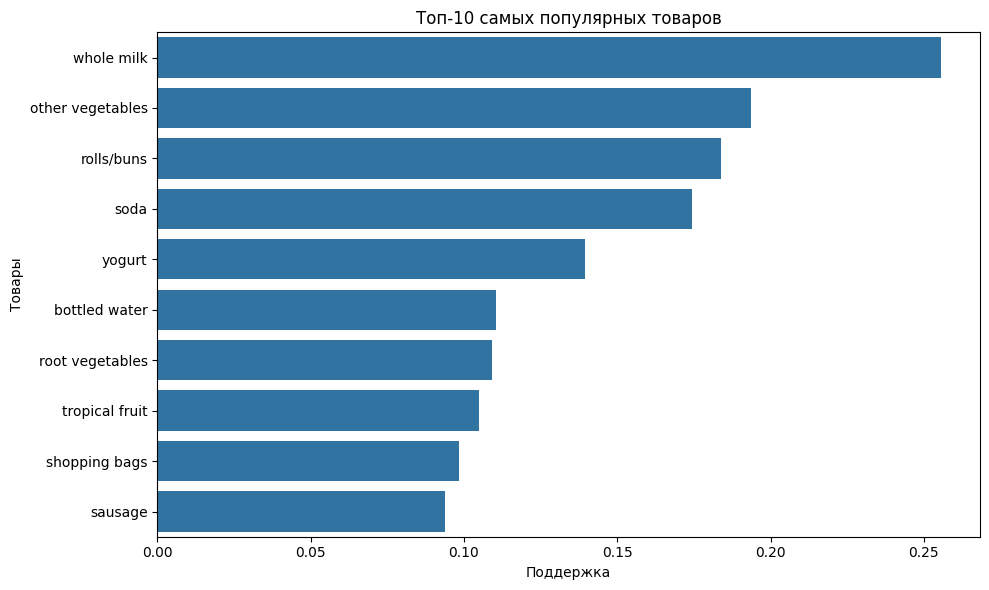

In [9]:
# Преобразуем множества в строки
apriori_frequent['itemsets'] = apriori_frequent['itemsets'].apply(lambda x: ', '.join(list(x)))

# Топ-10 продуктов по поддержке
top_products = apriori_frequent.sort_values(by='support', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title('Топ-10 самых популярных товаров')
plt.xlabel('Поддержка')
plt.ylabel('Товары')
plt.tight_layout()
plt.show()


Визуализация достоверности (confidence)

Создается столбчатая диаграмма, где по оси X - ассоциативные правила в виде «если -> то», а по оси Y - уровень достоверности (насколько часто правило выполняется). Такой график показывает, какие связи между товарами наиболее сильные и надёжные.

Самые сильные связи наблюдаются у пар «root vegetables - other vegetables», «whipped/sour cream - whole milk» и «root vegetables - whole milk» - их вероятность совместной покупки выше 0.4.
Большинство остальных правил имеют достоверность около 0.3-0.38, что говорит о средне выраженной, но устойчивой зависимости между товарами.

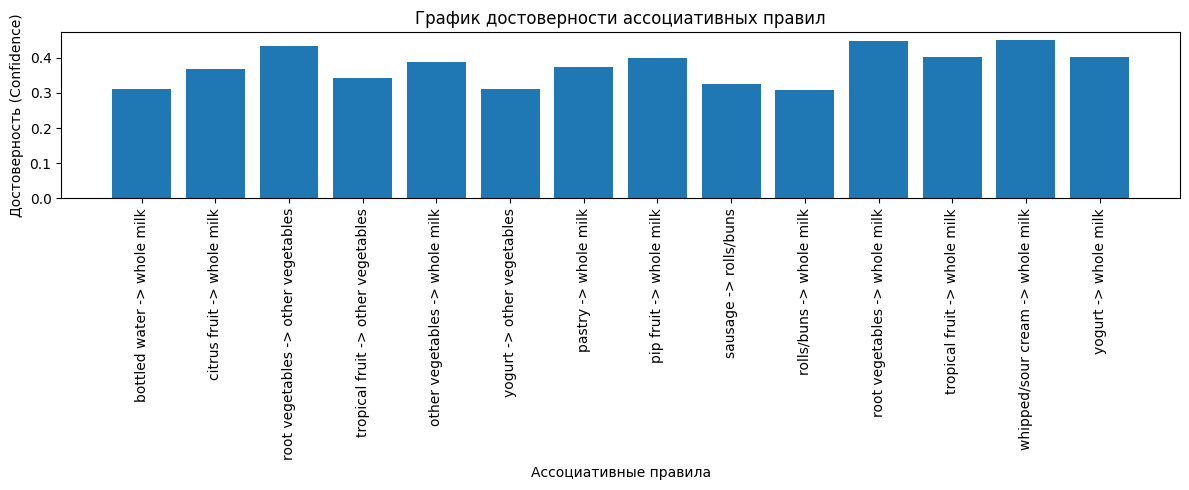

In [14]:
rules = apriori_rules.copy()
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Столбчатая диаграмма достоверности
plt.figure(figsize=(12, 5))
plt.bar(
    [f"{a} -> {c}" for a, c in zip(rules['antecedents'], rules['consequents'])],
    rules['confidence']
)
plt.xlabel("Ассоциативные правила")
plt.ylabel("Достоверность (Confidence)")
plt.title("График достоверности ассоциативных правил")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Сетевой граф ассоциативных правил

Построение графа с помощью networkx, где вершины - это товары, а рёбра - найденные зависимости между ними. Визуализация показывает, какие товары чаще всего покупаются вместе.

В центре находится узел whole milk - «цельное молоко», вокруг которого сгруппированы другие популярные продукты. Это означает, что молоко часто покупают вместе с ними. Толщина линий и подписи (например, 0.40 или 0.45) показывают уровень уверенности (confidence), то есть вероятность того, что покупка одного товара сопровождается покупкой другого. Из графа видно, что «цельное молоко» тесно связано с «йогуртом», «овощами», «тропическими фруктами» и «сметаной» - эти продукты часто встречаются в одних корзинах. Есть и более слабые связи, например между «булочками» и «колбасой». Это помогает понять покупательские привычки: молочные продукты и свежие фрукты/овощи часто идут вместе, а выпечка и мясные изделия формируют отдельные кластеры.

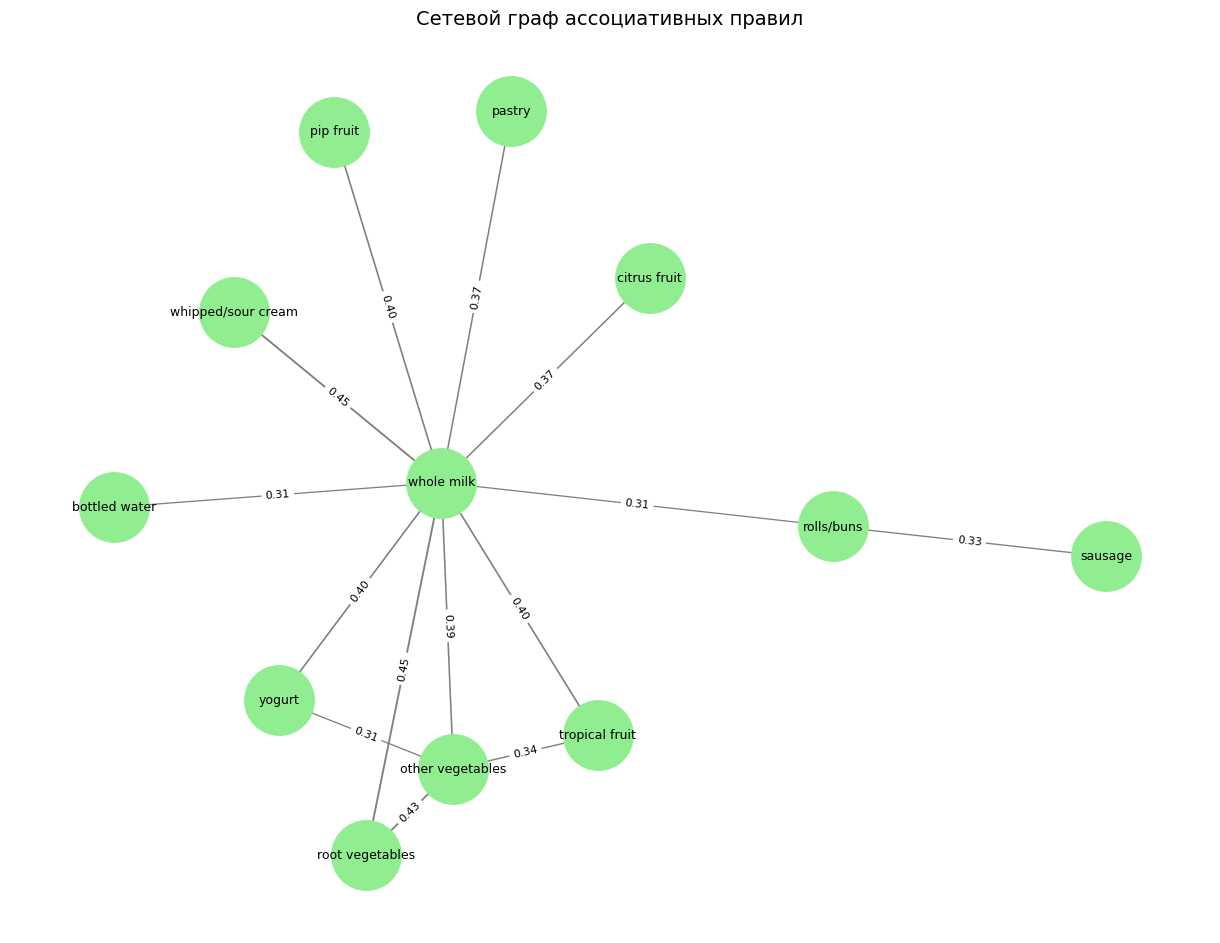

In [11]:
# Выбери, какие правила отображать: Apriori или FPGrowth
# rules = apriori_rules.copy()
rules = fpg_rules.copy()        

# Создаем граф на основе confidence
G = nx.Graph()
for _, row in rules.iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    G.add_edge(antecedent, consequent, weight=row['confidence'])

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, k=1.0, iterations=200, seed=42)
weights = [G[u][v]['weight'] for u, v in G.edges()]

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    node_color='lightgreen',
    font_size=9,
    edge_color='gray',
    width=[w * 3 for w in weights]
)

edge_labels = {k: f"{v:.2f}" for k, v in nx.get_edge_attributes(G, 'weight').items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title('Сетевой граф ассоциативных правил', fontsize=14)
plt.show()



Эксперименты с параметрами min_support и confidence

Для понимания влияния порогов на количество найденных правил запускаются эксперименты с разными значениями минимальной поддержки и достоверности. Результаты собираются в таблицу и визуализируются в виде тепловой карты. Это позволяет подобрать оптимальные параметры.

При min_support = 0.02 и confidence = 0.3 алгоритм находит 37 правил - максимум. Когда пороги повышаются, число правил резко сокращается: при confidence 0.5 остаётся всего одно правило, а при более высокой поддержке (0.04–0.05) почти ничего не находится.

    min_support  min_confidence  num_rules
0          0.02             0.3         37
1          0.02             0.4         15
2          0.02             0.5          1
3          0.03             0.3         14
4          0.03             0.4          5
5          0.03             0.5          0
6          0.04             0.3          7
7          0.04             0.4          4
8          0.04             0.5          0
9          0.05             0.3          3
10         0.05             0.4          1
11         0.05             0.5          0


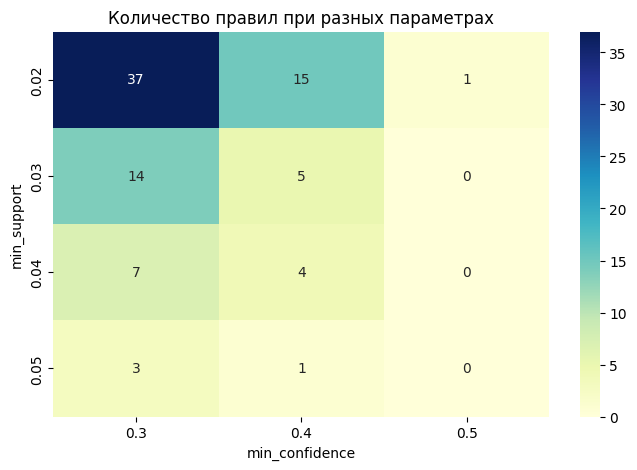

In [12]:
# Пример изменения параметров
supports = [0.02, 0.03, 0.04, 0.05]
confidences = [0.3, 0.4, 0.5]

results = []

for s in supports:
    for c in confidences:
        freq = apriori(data, min_support=s, use_colnames=True)
        rules_temp = association_rules(freq, metric="confidence", min_threshold=c)
        results.append({
            'min_support': s,
            'min_confidence': c,
            'num_rules': len(rules_temp)
        })

df_results = pd.DataFrame(results)
print(df_results)

pivot_table = df_results.pivot(
    index='min_support',
    columns='min_confidence',
    values='num_rules'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Количество правил при разных параметрах')
plt.xlabel('min_confidence')
plt.ylabel('min_support')
plt.show()

Минимальные значения поддержки для разных размеров наборов

Проверяется, как изменяется поддержка для наборов из 1, 2 и 3 товаров. Вычисляются минимальные и средние значения поддержки для каждой группы. Это нужно, чтобы понять, насколько часто встречаются комбинации разных размеров и как сложность набора влияет на частоту его появления.

Результаты показывают, что одиночные товары встречаются чаще всего - их средняя поддержка около 6.2%. Для пар товаров поддержка уже падает до 2.9%, а для троек - до 2.3%. Это логично: чем больше товаров в наборе, тем реже они встречаются вместе.

In [15]:
# Определение минимальной поддержки для наборов из 1, 2 и 3 элементов
for k in [1, 2, 3]:
    freq = apriori(data, min_support=0.02, use_colnames=True)
    subset = freq[freq['itemsets'].apply(lambda x: len(x) == k)]
    print(f"\nНаборы из {k} элементов")
    print(f"Минимальная поддержка: {subset['support'].min():.4f}")
    print(f"Средняя поддержка: {subset['support'].mean():.4f}")



Наборы из 1 элементов
Минимальная поддержка: 0.0210
Средняя поддержка: 0.0620

Наборы из 2 элементов
Минимальная поддержка: 0.0200
Средняя поддержка: 0.0295

Наборы из 3 элементов
Минимальная поддержка: 0.0223
Средняя поддержка: 0.0227
